In [9]:
# ============================================================
# 1. Imports and data loading
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from IPython.display import display

from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
)
from sklearn.impute import SimpleImputer


sns.set(style="whitegrid")


PATH = "synthetic_biomass_gasification_200rows_v3.csv"
df = pd.read_csv(PATH)

# Quick look
display(df.head())
print("Shape:", df.shape)
print("\nDtypes:\n", df.dtypes)

print("\nMissing values per column:\n", df.isna().sum())

print("\nInfo:")
print(df.info())

display(df.describe(include="number").round(3))
display(df.describe(include="object"))


,Temperature_C,ER,Gasifying_Agent,Reactor_Type,Moisture_wt_pct,Pressure_bar,H2_mol_per_Nm3,CO2_mol_per_Nm3,CO_mol_per_Nm3,CH4_mol_per_Nm3,N2_mol_per_Nm3,tar_g_per_Nm3,char_g_per_kg_feed
0,880.0,0.000,Steam,DFB,7.8,1.0,22.30,10.90,9.26,1.440,0.237,0.290,7.53
1,833.0,0.369,Air,CFB,10.8,1.0,3.57,8.09,6.57,0.361,25.600,0.677,13.70
2,990.0,0.000,Steam,Downdraft,13.8,5.0,22.30,10.30,8.74,2.500,0.229,0.111,6.80
3,933.0,0.109,Steam+O2,CFB,19.8,1.0,19.50,8.07,14.50,1.070,1.050,1.300,14.10
4,773.0,0.000,Steam,CFB,22.6,15.0,19.10,12.80,6.98,4.840,0.204,3.740,42.60


Shape: (200, 13)

Dtypes:
 Temperature_C         float64
ER                    float64
Gasifying_Agent        object
Reactor_Type           object
Moisture_wt_pct       float64
Pressure_bar          float64
H2_mol_per_Nm3        float64
CO2_mol_per_Nm3       float64
CO_mol_per_Nm3        float64
CH4_mol_per_Nm3       float64
N2_mol_per_Nm3        float64
tar_g_per_Nm3         float64
char_g_per_kg_feed    float64
dtype: object

Missing values per column:
 Temperature_C         0
ER                    0
Gasifying_Agent       0
Reactor_Type          0
Moisture_wt_pct       0
Pressure_bar          0
H2_mol_per_Nm3        0
CO2_mol_per_Nm3       0
CO_mol_per_Nm3        0
CH4_mol_per_Nm3       0
N2_mol_per_Nm3        0
tar_g_per_Nm3         0
char_g_per_kg_feed    0
dtype: int64

Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 13 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   

,Temperature_C,ER,Moisture_wt_pct,Pressure_bar,H2_mol_per_Nm3,CO2_mol_per_Nm3,CO_mol_per_Nm3,CH4_mol_per_Nm3,N2_mol_per_Nm3,tar_g_per_Nm3,char_g_per_kg_feed
count,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000,200.000
mean,837.775,0.224,15.544,4.100,10.795,9.042,9.899,1.654,12.753,2.129,17.764
std,56.025,0.118,6.115,5.256,7.406,1.913,3.751,1.138,12.126,2.325,10.262
min,705.000,0.000,2.000,1.000,0.661,5.090,4.190,0.040,0.113,0.037,4.330
25%,799.000,0.164,11.600,1.000,3.698,7.547,6.785,0.767,0.503,0.338,9.753
50%,835.000,0.229,16.300,1.000,9.690,9.110,8.530,1.375,12.250,1.155,14.350
75%,868.250,0.306,19.425,5.000,17.900,10.500,13.700,2.545,24.900,3.275,23.075
max,1000.000,0.442,34.400,20.000,22.700,13.700,17.000,4.840,26.800,13.600,57.100


,Gasifying_Agent,Reactor_Type
count,200,200
unique,4,4
top,Air,BFB
freq,100,71


In [10]:
# ============================================================
# 2. Stratified train/test split (stratify on ER)
# ============================================================


er_bins = [0.0, 0.10, 0.20, 0.30, 0.50]  # (covers ER from 0.0 to ~0.44)
df["ER_cat"] = pd.cut(
    df["ER"],
    bins=er_bins,
    labels=[1, 2, 3, 4],
    include_lowest=True,
)

print("ER_cat value proportions:")
print(df["ER_cat"].value_counts(normalize=True).sort_index())

split = StratifiedShuffleSplit(
    n_splits=1, test_size=0.2, random_state=42
)

for train_idx, test_idx in split.split(df, df["ER_cat"]):
    strat_train_set = df.loc[train_idx].drop(columns=["ER_cat"])
    strat_test_set = df.loc[test_idx].drop(columns=["ER_cat"])

print("\nTrain set shape:", strat_train_set.shape)
print("Test set shape:", strat_test_set.shape)


def er_cat_proportions(data):
    er_cat = pd.cut(
        data["ER"], bins=er_bins, labels=[1, 2, 3, 4], include_lowest=True
    )
    return er_cat.value_counts(normalize=True).sort_index()

print("\nOverall ER_cat distribution:\n", er_cat_proportions(df))
print("\nTrain ER_cat distribution:\n", er_cat_proportions(strat_train_set))
print("\nTest ER_cat distribution:\n", er_cat_proportions(strat_test_set))


ER_cat value proportions:
ER_cat
1    0.125
2    0.280
3    0.330
4    0.265
Name: proportion, dtype: float64

Train set shape: (160, 13)
Test set shape: (40, 13)

Overall ER_cat distribution:
 ER
1    0.125
2    0.280
3    0.330
4    0.265
Name: proportion, dtype: float64

Train ER_cat distribution:
 ER
1    0.12500
2    0.28125
3    0.33125
4    0.26250
Name: proportion, dtype: float64

Test ER_cat distribution:
 ER
1    0.125
2    0.275
3    0.325
4    0.275
Name: proportion, dtype: float64


In [11]:
# ============================================================
# 3. Separate features and multi-output targets
# ============================================================

FEATURE_COLS = [
    "Temperature_C",
    "ER",
    "Gasifying_Agent",
    "Reactor_Type",
    "Moisture_wt_pct",
    "Pressure_bar",
]

TARGET_COLS = [
    "H2_mol_per_Nm3",
    "CO2_mol_per_Nm3",
    "CO_mol_per_Nm3",
    "CH4_mol_per_Nm3",
    "N2_mol_per_Nm3",
    "tar_g_per_Nm3",
    "char_g_per_kg_feed",
]

train_set = strat_train_set.copy()
test_set = strat_test_set.copy()

X_train = train_set[FEATURE_COLS].copy()
y_train = train_set[TARGET_COLS].copy()

X_test = test_set[FEATURE_COLS].copy()
y_test = test_set[TARGET_COLS].copy()

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)


X_train shape: (160, 6)
y_train shape: (160, 7)


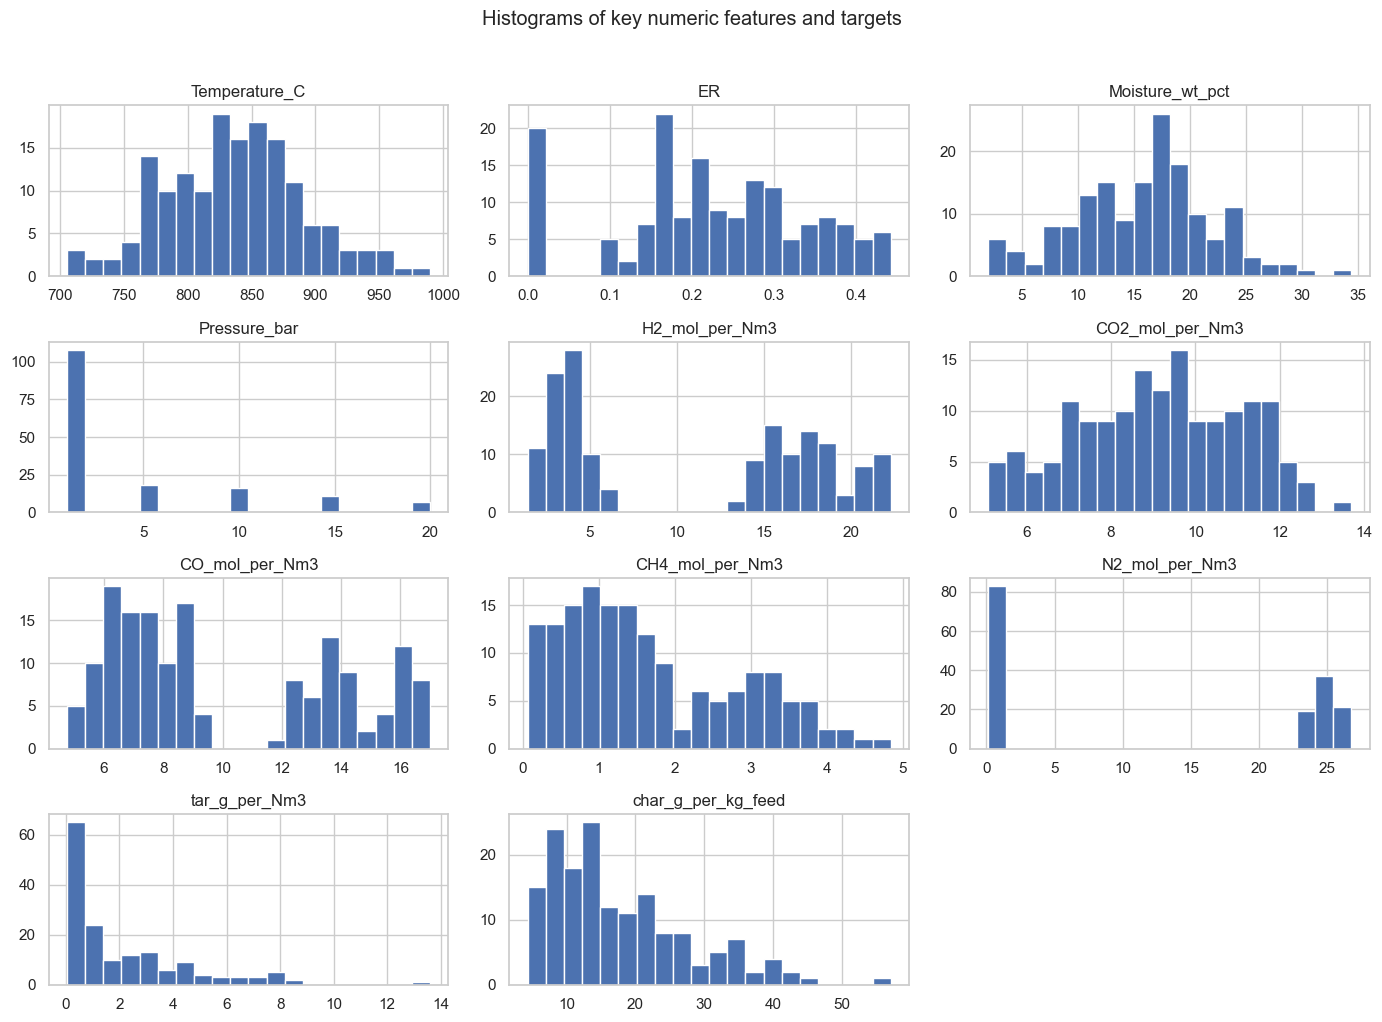

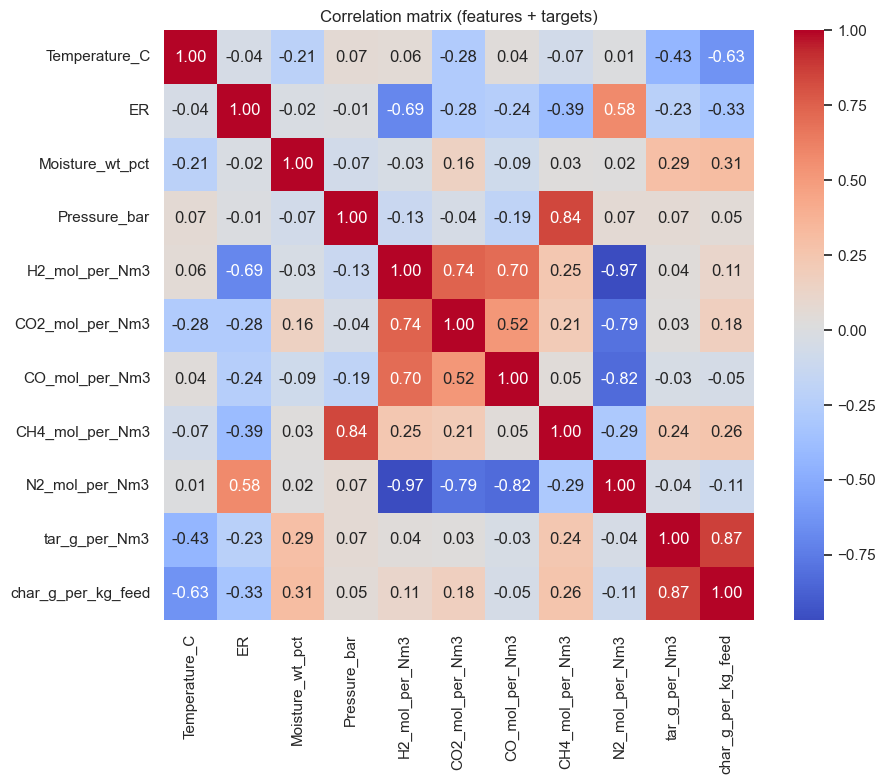


Correlations with H2_mol_per_Nm3:
H2_mol_per_Nm3        1.000
CO2_mol_per_Nm3       0.739
CO_mol_per_Nm3        0.704
CH4_mol_per_Nm3       0.246
char_g_per_kg_feed    0.110
Temperature_C         0.058
tar_g_per_Nm3         0.036
Moisture_wt_pct      -0.032
Pressure_bar         -0.128
ER                   -0.693
N2_mol_per_Nm3       -0.969
Name: H2_mol_per_Nm3, dtype: float64


In [12]:
# ============================================================
# 4. Exploratory Data Analysis on the TRAINING set only
# ============================================================

# ---- 4.1 Numeric distributions ----
numeric_cols_for_hist = [
    "Temperature_C",
    "ER",
    "Moisture_wt_pct",
    "Pressure_bar",
    "H2_mol_per_Nm3",
    "CO2_mol_per_Nm3",
    "CO_mol_per_Nm3",
    "CH4_mol_per_Nm3",
    "N2_mol_per_Nm3",
    "tar_g_per_Nm3",
    "char_g_per_kg_feed",
]

train_set[numeric_cols_for_hist].hist(
    bins=20, figsize=(14, 10)
)
plt.suptitle("Histograms of key numeric features and targets", y=1.02)
plt.tight_layout()
plt.show()

# ---- 4.2 Correlation matrix ----
corr_matrix = train_set.corr(numeric_only=True)

plt.figure(figsize=(10, 8))
sns.heatmap(
    corr_matrix,
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    square=True,
)
plt.title("Correlation matrix (features + targets)")
plt.tight_layout()
plt.show()


print("\nCorrelations with H2_mol_per_Nm3:")
print(
    corr_matrix["H2_mol_per_Nm3"]
    .sort_values(ascending=False)
    .round(3)
)






C:\Users\Shawn\AppData\Local\Temp\ipykernel_11720\2056594916.py:10: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Shawn\anaconda3\envs\CMSE492\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


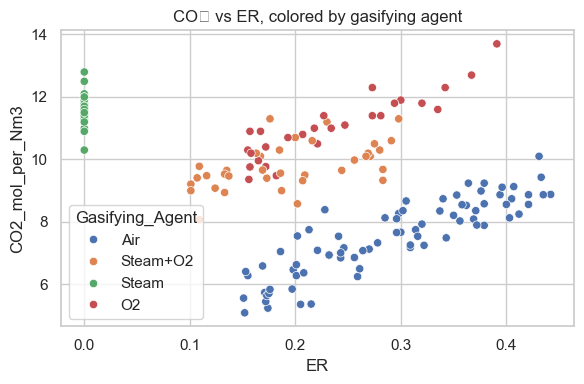

C:\Users\Shawn\AppData\Local\Temp\ipykernel_11720\2056594916.py:22: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Shawn\anaconda3\envs\CMSE492\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


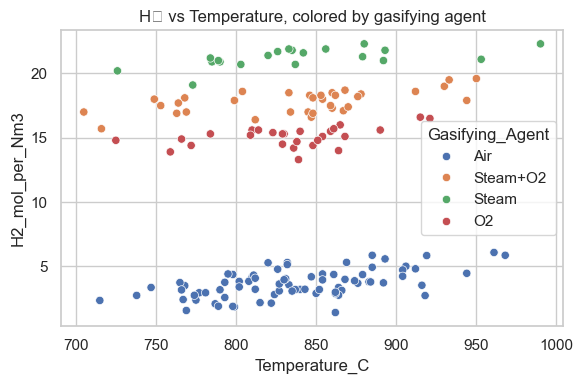

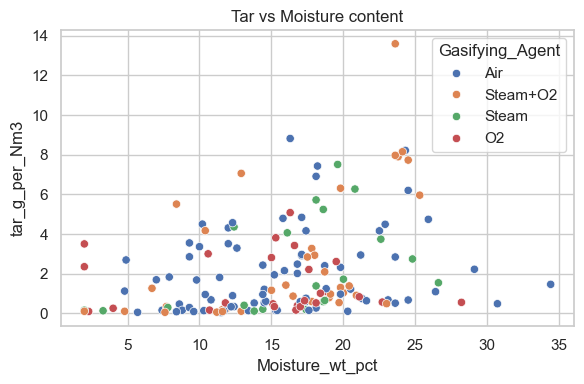

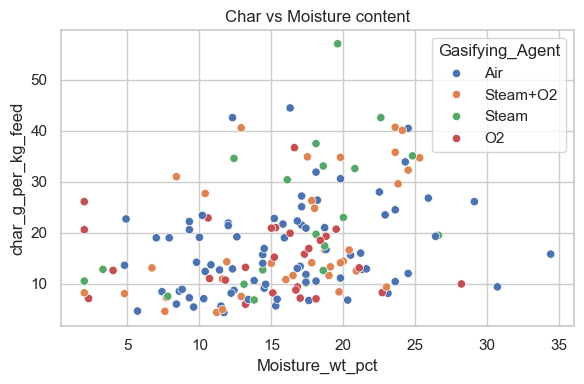

C:\Users\Shawn\AppData\Local\Temp\ipykernel_11720\2056594916.py:57: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  plt.tight_layout()
C:\Users\Shawn\anaconda3\envs\CMSE492\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 8322 (\N{SUBSCRIPT TWO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)


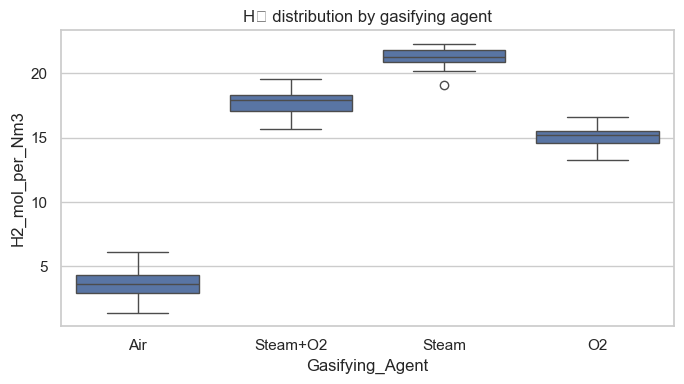

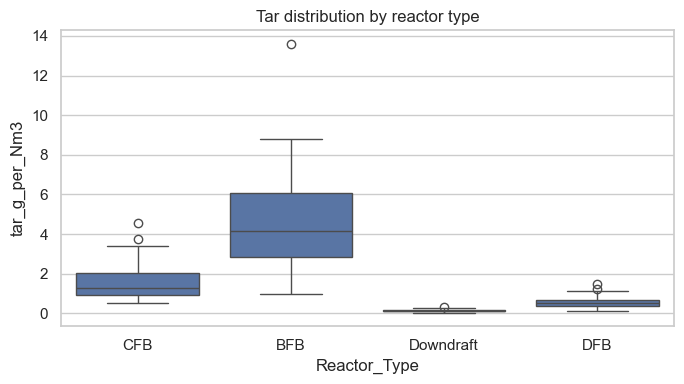

In [13]:
# ---- 4.3 CO2 vs ER ----
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=train_set,
    x="ER",
    y="CO2_mol_per_Nm3",
    hue="Gasifying_Agent",
)
plt.title("CO₂ vs ER, colored by gasifying agent")
plt.tight_layout()
plt.show()

# ---- 4.4 H2 vs Temperature ----
plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=train_set,
    x="Temperature_C",
    y="H2_mol_per_Nm3",
    hue="Gasifying_Agent",
)
plt.title("H₂ vs Temperature, colored by gasifying agent")
plt.tight_layout()
plt.show()


# ---- 4.5 Moisture content plots (tar + char) ----

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=train_set,
    x="Moisture_wt_pct",
    y="tar_g_per_Nm3",
    hue="Gasifying_Agent",
)
plt.title("Tar vs Moisture content")
plt.tight_layout()
plt.show()

plt.figure(figsize=(6, 4))
sns.scatterplot(
    data=train_set,
    x="Moisture_wt_pct",
    y="char_g_per_kg_feed",
    hue="Gasifying_Agent",
)
plt.title("Char vs Moisture content")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=train_set,
    x="Gasifying_Agent",
    y="H2_mol_per_Nm3",
)
plt.title("H₂ distribution by gasifying agent")
plt.tight_layout()
plt.show()

plt.figure(figsize=(7, 4))
sns.boxplot(
    data=train_set,
    x="Reactor_Type",
    y="tar_g_per_Nm3",
)
plt.title("Tar distribution by reactor type")
plt.tight_layout()
plt.show()


In [14]:
# ============================================================
# 5. Feature engineering + preprocessing pipeline
#    (for models you'll add later)
# ============================================================

#   - Moisture_frac = Moisture_wt_pct / 100
#   - ER_sq = ER² (nonlinear effect of ER)
#   - Temp_x_ER = Temperature * ER (interaction term)

def add_gasification_features(X: pd.DataFrame) -> pd.DataFrame:
    X = X.copy()
    X["Moisture_frac"] = X["Moisture_wt_pct"] / 100.0
    X["ER_sq"] = X["ER"] ** 2
    X["Temp_x_ER"] = X["Temperature_C"] * X["ER"]
    return X

feature_engineering = FunctionTransformer(
    add_gasification_features,
    validate=False,   
)

numeric_features = [
    "Temperature_C",
    "ER",
    "Moisture_wt_pct",
    "Pressure_bar",
    "Moisture_frac",
    "ER_sq",
    "Temp_x_ER",
]

categorical_features = ["Gasifying_Agent", "Reactor_Type"]

numeric_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", StandardScaler()),
    ]
)

categorical_pipeline = Pipeline(
    steps=[
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("onehot", OneHotEncoder(handle_unknown="ignore")),
    ]
)

preprocessing = Pipeline(
    steps=[
        ("feature_engineering", feature_engineering),
        (
            "column_transformer",
            ColumnTransformer(
                transformers=[
                    ("num", numeric_pipeline, numeric_features),
                    ("cat", categorical_pipeline, categorical_features),
                ]
            ),
        ),
    ]
)

# Fit the preprocessing pipeline on the training data only
X_train_prepared = preprocessing.fit_transform(X_train)
X_test_prepared = preprocessing.transform(X_test)

print("Prepared X_train shape:", X_train_prepared.shape)
print("Prepared X_test shape:", X_test_prepared.shape)


Prepared X_train shape: (160, 15)
Prepared X_test shape: (40, 15)


In [30]:
# ============================================================
# MODELING SECTION – THREE MODELS + TUNING + EVALUATION
# Assumes you already have:
#   X_train, X_test, y_train, y_test
#   preprocessing  (Pipeline: feature engineering + scaling + one-hot)
# ============================================================

import time
import numpy as np
import pandas as pd

from sklearn.linear_model import Ridge
from sklearn.svm import SVR
from sklearn.multioutput import MultiOutputRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error

# ------------------------------------------------------------
# Helper: compute R2, MAE, RMSE for multi-output regression
# ------------------------------------------------------------
def compute_metrics(y_true, y_pred):
    """
    Returns (R2, MAE, RMSE), each averaged over all output columns.
    This version avoids the 'squared' keyword argument so it works
    on older scikit-learn versions.
    """
    # scikit-learn's default for multi-output is 'uniform_average',
    # so we don't pass multioutput=... here.
    r2 = r2_score(y_true, y_pred)
    mae = mean_absolute_error(y_true, y_pred)
    mse = mean_squared_error(y_true, y_pred)
    rmse = np.sqrt(mse)
    return r2, mae, rmse


# Dictionary to store results for all models
model_results = []

# ============================================================
# MODEL 1: Linear Ridge Regression (simple model)
# ============================================================

print("===== MODEL 1: Ridge Regression =====")

ridge_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessing),
        ("model", Ridge())   # no random_state; Ridge is deterministic
    ]
)

ridge_param_grid = {
    "model__alpha": [0.01, 0.1, 1.0, 10.0, 100.0],
    "model__fit_intercept": [True, False],
}

ridge_grid = GridSearchCV(
    estimator=ridge_pipe,
    param_grid=ridge_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)

t0 = time.perf_counter()
ridge_grid.fit(X_train, y_train)
ridge_train_time = time.perf_counter() - t0

best_ridge = ridge_grid.best_estimator_

print("Best Ridge params:", ridge_grid.best_params_)
print("Best Ridge CV score (MSE):", -ridge_grid.best_score_)

t0 = time.perf_counter()
y_pred_ridge = best_ridge.predict(X_test)
ridge_infer_time = time.perf_counter() - t0

ridge_r2, ridge_mae, ridge_rmse = compute_metrics(y_test, y_pred_ridge)
print(f"Ridge test metrics -> R2: {ridge_r2:.4f}, MAE: {ridge_mae:.4f}, RMSE: {ridge_rmse:.4f}")

model_results.append({
    "Model": "Ridge Regression",
    "R2": ridge_r2,
    "MAE": ridge_mae,
    "RMSE": ridge_rmse,
    "Train_time_s": ridge_train_time,
    "Infer_time_s": ridge_infer_time
})


# ============================================================
# MODEL 2: Support Vector Regression with RBF kernel
#          (intermediate complexity)
# ============================================================

print("\n===== MODEL 2: SVR (RBF kernel) =====")

# Base SVR for a single output
base_svr = SVR(kernel="rbf")

svr_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessing),
        ("model", MultiOutputRegressor(base_svr)),
    ]
)

svr_param_grid = {
    "model__estimator__C": [10, 50, 100],
    "model__estimator__epsilon": [0.1, 0.5, 1.0],
    "model__estimator__gamma": ["scale"],  # keep small grid to avoid huge runtimes
}

svr_grid = GridSearchCV(
    estimator=svr_pipe,
    param_grid=svr_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)

t0 = time.perf_counter()
svr_grid.fit(X_train, y_train)
svr_train_time = time.perf_counter() - t0

best_svr = svr_grid.best_estimator_

print("Best SVR params:", svr_grid.best_params_)
print("Best SVR CV score (MSE):", -svr_grid.best_score_)

t0 = time.perf_counter()
y_pred_svr = best_svr.predict(X_test)
svr_infer_time = time.perf_counter() - t0

svr_r2, svr_mae, svr_rmse = compute_metrics(y_test, y_pred_svr)
print(f"SVR test metrics -> R2: {svr_r2:.4f}, MAE: {svr_mae:.4f}, RMSE: {svr_rmse:.4f}")

model_results.append({
    "Model": "SVR (RBF)",
    "R2": svr_r2,
    "MAE": svr_mae,
    "RMSE": svr_rmse,
    "Train_time_s": svr_train_time,
    "Infer_time_s": svr_infer_time
})


# ============================================================
# MODEL 3: Random Forest Regressor (more complex model)
# ============================================================

print("\n===== MODEL 3: Random Forest =====")

rf_pipe = Pipeline(
    steps=[
        ("preprocess", preprocessing),
        ("model", RandomForestRegressor(
            random_state=42,
            n_jobs=-1
        )),
    ]
)

rf_param_grid = {
    "model__n_estimators": [100, 300],
    "model__max_depth": [None, 20],
    "model__min_samples_split": [2, 5],
    "model__min_samples_leaf": [1, 2],
    "model__max_features": ["sqrt"],
}

rf_grid = GridSearchCV(
    estimator=rf_pipe,
    param_grid=rf_param_grid,
    scoring="neg_mean_squared_error",
    cv=5,
    n_jobs=-1,
)

t0 = time.perf_counter()
rf_grid.fit(X_train, y_train)
rf_train_time = time.perf_counter() - t0

best_rf = rf_grid.best_estimator_

print("Best RF params:", rf_grid.best_params_)
print("Best RF CV score (MSE):", -rf_grid.best_score_)

t0 = time.perf_counter()
y_pred_rf = best_rf.predict(X_test)
rf_infer_time = time.perf_counter() - t0

rf_r2, rf_mae, rf_rmse = compute_metrics(y_test, y_pred_rf)
print(f"RF test metrics -> R2: {rf_r2:.4f}, MAE: {rf_mae:.4f}, RMSE: {rf_rmse:.4f}")

model_results.append({
    "Model": "Random Forest",
    "R2": rf_r2,
    "MAE": rf_mae,
    "RMSE": rf_rmse,
    "Train_time_s": rf_train_time,
    "Infer_time_s": rf_infer_time
})


# ============================================================
# SUMMARY TABLES
# ============================================================

results_df = pd.DataFrame(model_results)
print("\n===== SUMMARY: Test-set performance and timings =====")
display(results_df)

# If you want just the metrics table for your report:
metrics_table = results_df[["Model", "R2", "MAE", "RMSE"]]
timing_table = results_df[["Model", "Train_time_s", "Infer_time_s"]]

print("\nMetrics table:")
display(metrics_table.round(4))

print("\nTiming table:")
display(timing_table.round(4))


===== MODEL 1: Ridge Regression =====
Best Ridge params: {'model__alpha': 0.01, 'model__fit_intercept': True}
Best Ridge CV score (MSE): 1.7733728560399311
Ridge test metrics -> R2: 0.9465, MAE: 0.5856, RMSE: 1.2085

===== MODEL 2: SVR (RBF kernel) =====
Best SVR params: {'model__estimator__C': 50, 'model__estimator__epsilon': 0.1, 'model__estimator__gamma': 'scale'}
Best SVR CV score (MSE): 2.5334747576892562
SVR test metrics -> R2: 0.9552, MAE: 0.6854, RMSE: 1.2378

===== MODEL 3: Random Forest =====
Best RF params: {'model__max_depth': None, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 1, 'model__min_samples_split': 2, 'model__n_estimators': 300}
Best RF CV score (MSE): 6.0656817391481
RF test metrics -> R2: 0.8125, MAE: 1.1714, RMSE: 1.9372

===== SUMMARY: Test-set performance and timings =====


,Model,R2,MAE,RMSE,Train_time_s,Infer_time_s
0,Ridge Regression,0.946480,0.585553,1.208549,5.218578,0.013656
1,SVR (RBF),0.955213,0.685356,1.237803,0.461100,0.017262
2,Random Forest,0.812525,1.171408,1.937244,4.189311,0.076633



Metrics table:


,Model,R2,MAE,RMSE
0,Ridge Regression,0.9465,0.5856,1.2085
1,SVR (RBF),0.9552,0.6854,1.2378
2,Random Forest,0.8125,1.1714,1.9372



Timing table:


,Model,Train_time_s,Infer_time_s
0,Ridge Regression,5.2186,0.0137
1,SVR (RBF),0.4611,0.0173
2,Random Forest,4.1893,0.0766


Plotting learning curve for Ridge Regression...


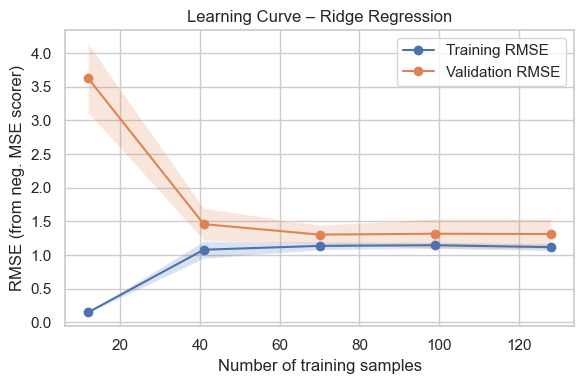

Plotting learning curve for SVR (RBF)...


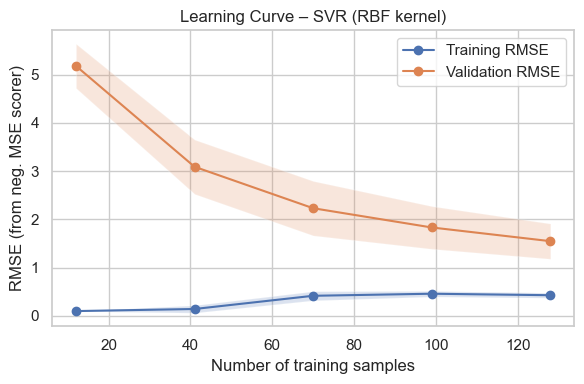

Plotting learning curve for Random Forest...


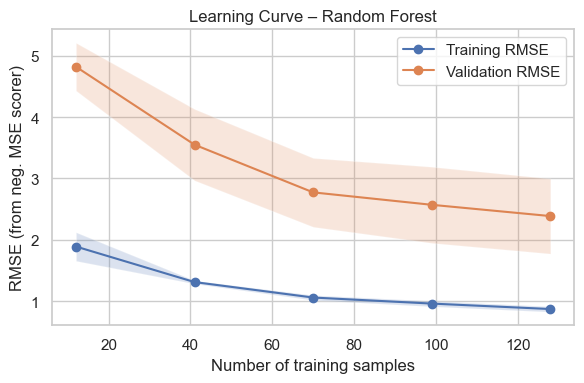

In [31]:
# ============================================================
# LEARNING CURVES FOR EACH MODEL
# ============================================================

import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import learning_curve

def plot_learning_curve_for_model(estimator, model_name, X, y, cv=5):
    """
    Plot learning curve (training vs validation RMSE) for a given estimator.
    Uses neg_mean_squared_error as the scoring metric and converts to RMSE.
    """
    train_sizes, train_scores, val_scores = learning_curve(
        estimator=estimator,
        X=X,
        y=y,
        cv=cv,
        scoring="neg_mean_squared_error",
        n_jobs=-1,
        train_sizes=np.linspace(0.1, 1.0, 5),
    )

 
    train_rmse = np.sqrt(-train_scores)
    val_rmse   = np.sqrt(-val_scores)

    train_mean = train_rmse.mean(axis=1)
    train_std  = train_rmse.std(axis=1)

    val_mean = val_rmse.mean(axis=1)
    val_std  = val_rmse.std(axis=1)

    # ---- Plot ----
    plt.figure(figsize=(6, 4))
    plt.plot(train_sizes, train_mean, "o-", label="Training RMSE")
    plt.plot(train_sizes, val_mean, "o-", label="Validation RMSE")

    plt.fill_between(
        train_sizes,
        train_mean - train_std,
        train_mean + train_std,
        alpha=0.2,
    )
    plt.fill_between(
        train_sizes,
        val_mean - val_std,
        val_mean + val_std,
        alpha=0.2,
    )

    plt.title(f"Learning Curve – {model_name}")
    plt.xlabel("Number of training samples")
    plt.ylabel("RMSE (from neg. MSE scorer)")
    plt.grid(True)
    plt.legend()
    plt.tight_layout()
    plt.show()


# ============================================================
# Generate learning curves for each tuned model
# ============================================================

print("Plotting learning curve for Ridge Regression...")
plot_learning_curve_for_model(best_ridge, "Ridge Regression", X_train, y_train, cv=5)

print("Plotting learning curve for SVR (RBF)...")
plot_learning_curve_for_model(best_svr, "SVR (RBF kernel)", X_train, y_train, cv=5)

print("Plotting learning curve for Random Forest...")
plot_learning_curve_for_model(best_rf, "Random Forest", X_train, y_train, cv=5)
